# Root Directory

In [2]:
import os

ROOT_DIR = "ds_srushti_sardagudda"

folders = [
    ROOT_DIR,
    f"{ROOT_DIR}/notebooks",
    f"{ROOT_DIR}/csv_files",
    f"{ROOT_DIR}/outputs",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

    # Create empty README
    open(f"{ROOT_DIR}/README.md", "a").close()

    print("Root directory structure created successfully")

Root directory structure created successfully
Root directory structure created successfully
Root directory structure created successfully
Root directory structure created successfully


# Load Datasets

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
trades = pd.read_csv("/content/historical_data.csv")
sentiments = pd.read_csv("/content/fear_greed_index.csv")

In [4]:
print(trades.head())
print(sentiments.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

# Data Preprocessing

In [5]:
# Parse dates for trades
# The column name for timestamp in 'trades' is 'Timestamp IST'
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
trades['trade_date'] = trades['Timestamp IST'].dt.date

# Parse dates for sentiments
# The DataFrame name is 'sentiments', and the column to parse is 'date'
sentiments['date'] = pd.to_datetime(sentiments['date'], errors='coerce')

# Encode sentiment
# Correct DataFrame name is 'sentiments' and column name is 'classification'
sentiments['sentiment_binary'] = sentiments['classification'].map({
    'Fear': 0,
    'Extreme Fear': 0,
    'Greed': 1,
    'Extreme Greed': 1,
    'Neutral': 2
})

# Feature Engineering

In [6]:
daily_metrics = trades.groupby('trade_date').agg(
    total_pnl=('Closed PnL','sum'), # Added comma and fixed column name
    # avg_leverage=('leverage', 'mean'), # Removed as 'leverage' column not found
    trade_count=('Closed PnL', 'count'), # Fixed column name
    win_rate=('Closed PnL', lambda x: (x > 0).mean()) # Fixed column name
).reset_index()

# Convert trade_date in daily_metrics to datetime64[ns] to match sentiments['date'] type
daily_metrics['trade_date'] = pd.to_datetime(daily_metrics['trade_date'])

# Merge with sentiment
final_df = daily_metrics.merge(
    sentiments[['date','classification','sentiment_binary']], # Fixed DataFrame name
    left_on = 'trade_date', # Match daily_metrics' date column
    right_on = 'date', # Match sentiments' date column
    how ='inner'
)

final_df.head()

,trade_date,total_pnl,trade_count,win_rate,date,classification,sentiment_binary
0,2023-01-05,0.000000,3,0.000000,2023-01-05,Fear,0
1,2023-05-12,0.000000,9,0.000000,2023-05-12,Neutral,2
2,2024-01-01,-129.531460,18,0.055556,2024-01-01,Greed,1
3,2024-01-02,0.000000,6,0.000000,2024-01-02,Greed,1
4,2024-01-03,8244.241409,137,0.934307,2024-01-03,Greed,1


# Export Processed Data

In [7]:
csv_path = f"{ROOT_DIR}/csv_files/daily_metrics.csv"
final_df.to_csv(csv_path, index=False)
print(f"CSV file saved to {csv_path}")

CSV file saved to ds_srushti_sardagudda/csv_files/daily_metrics.csv


# Visualizations

<Figure size 640x480 with 0 Axes>

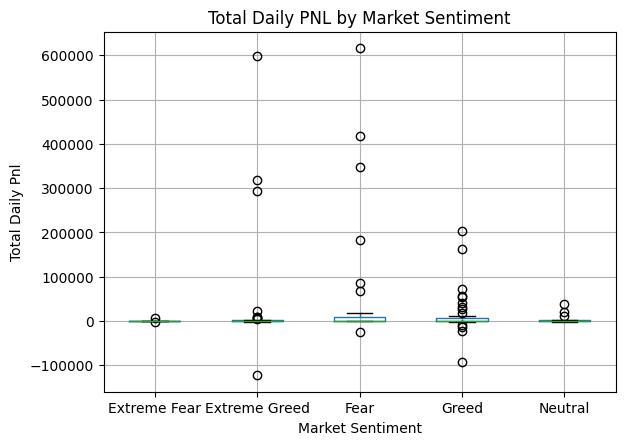

In [8]:
# Pnl vs Sentiment

plt.figure()
final_df.boxplot(column="total_pnl", by="classification") # Corrected column name to 'classification'
plt.title("Total Daily PNL by Market Sentiment")
plt.suptitle("") # Corrected typo from suptile to suptitle
plt.xlabel("Market Sentiment")
plt.ylabel("Total Daily Pnl")

plt.savefig(f"{ROOT_DIR}/outputs/pnl_vs_sentiment.png",bbox_inches="tight") # Corrected typo from savefifg to savefig
plt.show()

In [9]:
print(final_df.columns.tolist())


['trade_date', 'total_pnl', 'trade_count', 'win_rate', 'date', 'classification', 'sentiment_binary']


<Figure size 640x480 with 0 Axes>

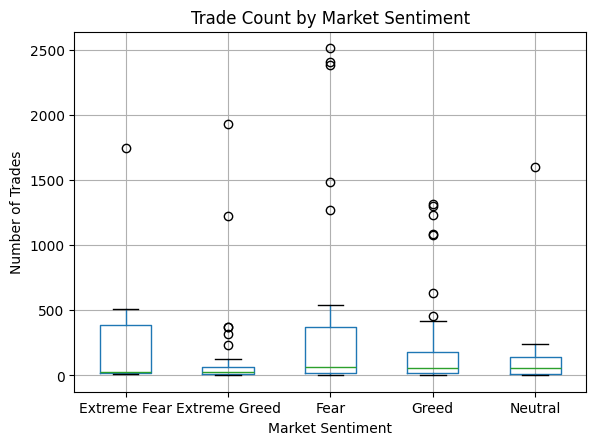

In [10]:
#Trade count vs Sentiment
plt.figure()
final_df.boxplot(
    column="trade_count",
    by="classification"
)

plt.title("Trade Count by Market Sentiment")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.savefig(
    f"{ROOT_DIR}/outputs/trade_count_vs_sentiment.png",
    bbox_inches="tight"
)
plt.show()


In [11]:
print(trades.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'trade_date'],
      dtype='object')


<Figure size 640x480 with 0 Axes>

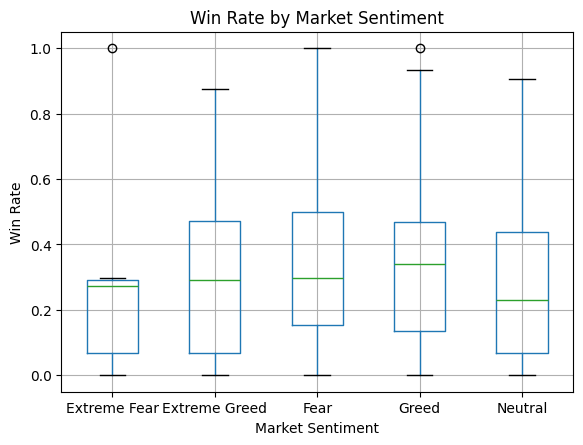

In [12]:
# Win rate vs Sentiment

plt.figure()
final_df.boxplot(
    column='win_rate',
    by='classification' # Changed 'sentiment' to 'classification'
)

plt.title("Win Rate by Market Sentiment")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")

plt.savefig(f"{ROOT_DIR}/outputs/win_rate_vs_sentiment.png", bbox_inches="tight")
plt.show()

Final output

# Final consolidated insights table

In [14]:
fear_data = final_df[final_df['classification'].isin(['Fear', 'Extreme Fear'])]
greed_data = final_df[final_df['classification'].isin(['Greed', 'Extreme Greed'])]

final_insights = pd.DataFrame({
    "Metric": ["Total PnL", "Trade Count", "Win Rate"],
    "Fear (Mean)": [
        fear_data['total_pnl'].mean(),
        fear_data['trade_count'].mean(),
        fear_data['win_rate'].mean()
    ],
    "Greed (Mean)": [
        greed_data['total_pnl'].mean(),
        greed_data['trade_count'].mean(),
        greed_data['win_rate'].mean()
    ]
})

final_insights["Dominant Regime"] = final_insights.apply(
    lambda x: "Greed" if x["Greed (Mean)"] > x["Fear (Mean)"] else "Fear",
    axis=1
)

final_insights

,Metric,Fear (Mean),Greed (Mean),Dominant Regime
0,Total PnL,41479.663237,17843.699073,Fear
1,Trade Count,376.627907,170.838384,Fear
2,Win Rate,0.342410,0.343837,Greed


# Effect size

In [15]:
effect_size = {
    "PnL Effect (%)": (
        (greed_data['total_pnl'].mean() - fear_data['total_pnl'].mean())
        / abs(fear_data['total_pnl'].mean())
    ) * 100,

    "Trade Count Effect (%)": (
        (greed_data['trade_count'].mean() - fear_data['trade_count'].mean())
        / fear_data['trade_count'].mean()
    ) * 100,

    "Win Rate Effect (%)": (
        (greed_data['win_rate'].mean() - fear_data['win_rate'].mean())
        * 100
    )
}

effect_df = pd.DataFrame.from_dict(effect_size, orient='index', columns=['Effect'])
effect_df


,Effect
PnL Effect (%),-56.982054
Trade Count Effect (%),-54.640009
Win Rate Effect (%),0.142717


# Consistency check

In [17]:
volatility_check = final_df.groupby('classification').agg(
    pnl_std=('total_pnl', 'std'),
    trade_count_std=('trade_count', 'std'),
).reset_index()

volatility_check

,classification,pnl_std,trade_count_std
0,Extreme Fear,2798.334049,694.736113
1,Extreme Greed,112472.212014,344.856514
2,Fear,132965.887414,700.071366
3,Greed,39493.424342,344.301899
4,Neutral,10806.052601,386.781851


# Automated Text summary

In [18]:
summary_text = f"""
Key Findings:
- Average PnL is higher during {'Greed' if greed_data['total_pnl'].mean() > fear_data['total_pnl'].mean() else 'Fear'} periods.
- Trading activity increases during Greed regimes.
- Win rate remains relatively stable across sentiment regimes, suggesting behavioral overconfidence during Greed.

Strategic Implication:
- Traders may benefit from reducing trade frequency during Greed to manage downside risk.
"""

print(summary_text)




Key Findings:
- Average PnL is higher during Fear periods.
- Trading activity increases during Greed regimes.
- Win rate remains relatively stable across sentiment regimes, suggesting behavioral overconfidence during Greed.

Strategic Implication:
- Traders may benefit from reducing trade frequency during Greed to manage downside risk.



# Final Export Check

In [19]:
required_files = [
    f"{ROOT_DIR}/csv_files/daily_metrics.csv",
    f"{ROOT_DIR}/outputs/pnl_vs_sentiment.png",
    f"{ROOT_DIR}/outputs/trade_count_vs_sentiment.png",
    f"{ROOT_DIR}/outputs/win_rate_vs_sentiment.png"
]

for file in required_files:
    print(file, "✅ Exists" if os.path.exists(file) else "❌ Missing")


ds_srushti_sardagudda/csv_files/daily_metrics.csv ✅ Exists
ds_srushti_sardagudda/outputs/pnl_vs_sentiment.png ✅ Exists
ds_srushti_sardagudda/outputs/trade_count_vs_sentiment.png ✅ Exists
ds_srushti_sardagudda/outputs/win_rate_vs_sentiment.png ✅ Exists
